In [ ]:
conda install seaborn -y

In [26]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
data = pd.read_csv("Test/real_estate_dataset.csv")


**Note:** Choose the option that matches your file location. The most common fix is ensuring pandas is imported and using the correct file path.

In [28]:
data.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [29]:
data.describe()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,174.640428,2.958000,1.976000,1.964000,1957.604000,0.536000,0.492000,30.174000,5.164410,10.469641,582209.629529
std,144.481833,74.672102,1.440968,0.820225,0.802491,35.491781,0.499202,0.500437,11.582575,2.853489,5.588197,122273.390345
min,1.000000,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,276892.470136
25%,125.750000,110.319923,2.000000,1.000000,1.000000,1926.000000,0.000000,0.000000,20.000000,2.760650,6.066754,503080.344140
50%,250.500000,178.290937,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.206518,10.886066,574724.113347
75%,375.250000,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.732933,15.072590,665942.301274
max,500.000000,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,960678.274291


In [30]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         500 non-null    float64
 2   Num_Bedrooms        500 non-null    int64  
 3   Num_Bathrooms       500 non-null    int64  
 4   Num_Floors          500 non-null    int64  
 5   Year_Built          500 non-null    int64  
 6   Has_Garden          500 non-null    int64  
 7   Has_Pool            500 non-null    int64  
 8   Garage_Size         500 non-null    int64  
 9   Location_Score      500 non-null    float64
 10  Distance_to_Center  500 non-null    float64
 11  Price               500 non-null    float64
dtypes: float64(4), int64(8)
memory usage: 47.0 KB


# Data preprocessing

In [31]:
# checking for missing values

In [32]:
data.isnull().sum()

ID                    0
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

# There are no missing values

In [33]:
# Handling outliers

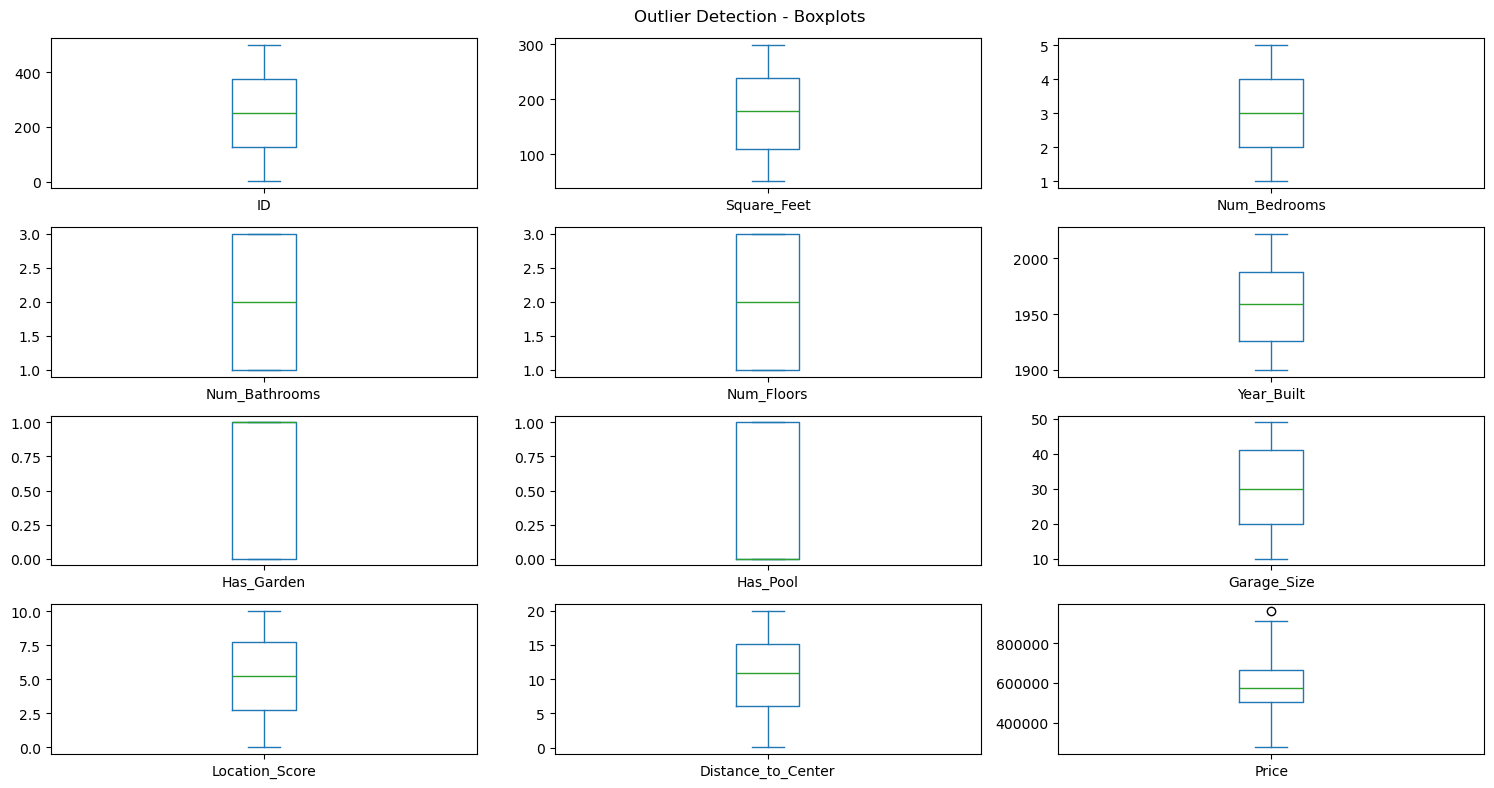

In [34]:
numerical_cols = data.select_dtypes(include='number').columns

data[numerical_cols].plot(kind='box', subplots=True, 
                         layout=(4, 3),        # adjust rows/cols as needed
                         figsize=(15, 8))
plt.suptitle("Outlier Detection - Boxplots")
plt.tight_layout()
plt.show()

# Here there is only one outlier in the price column, we can processed as it is only one outlier

In [35]:
# Normalizing the numerical features

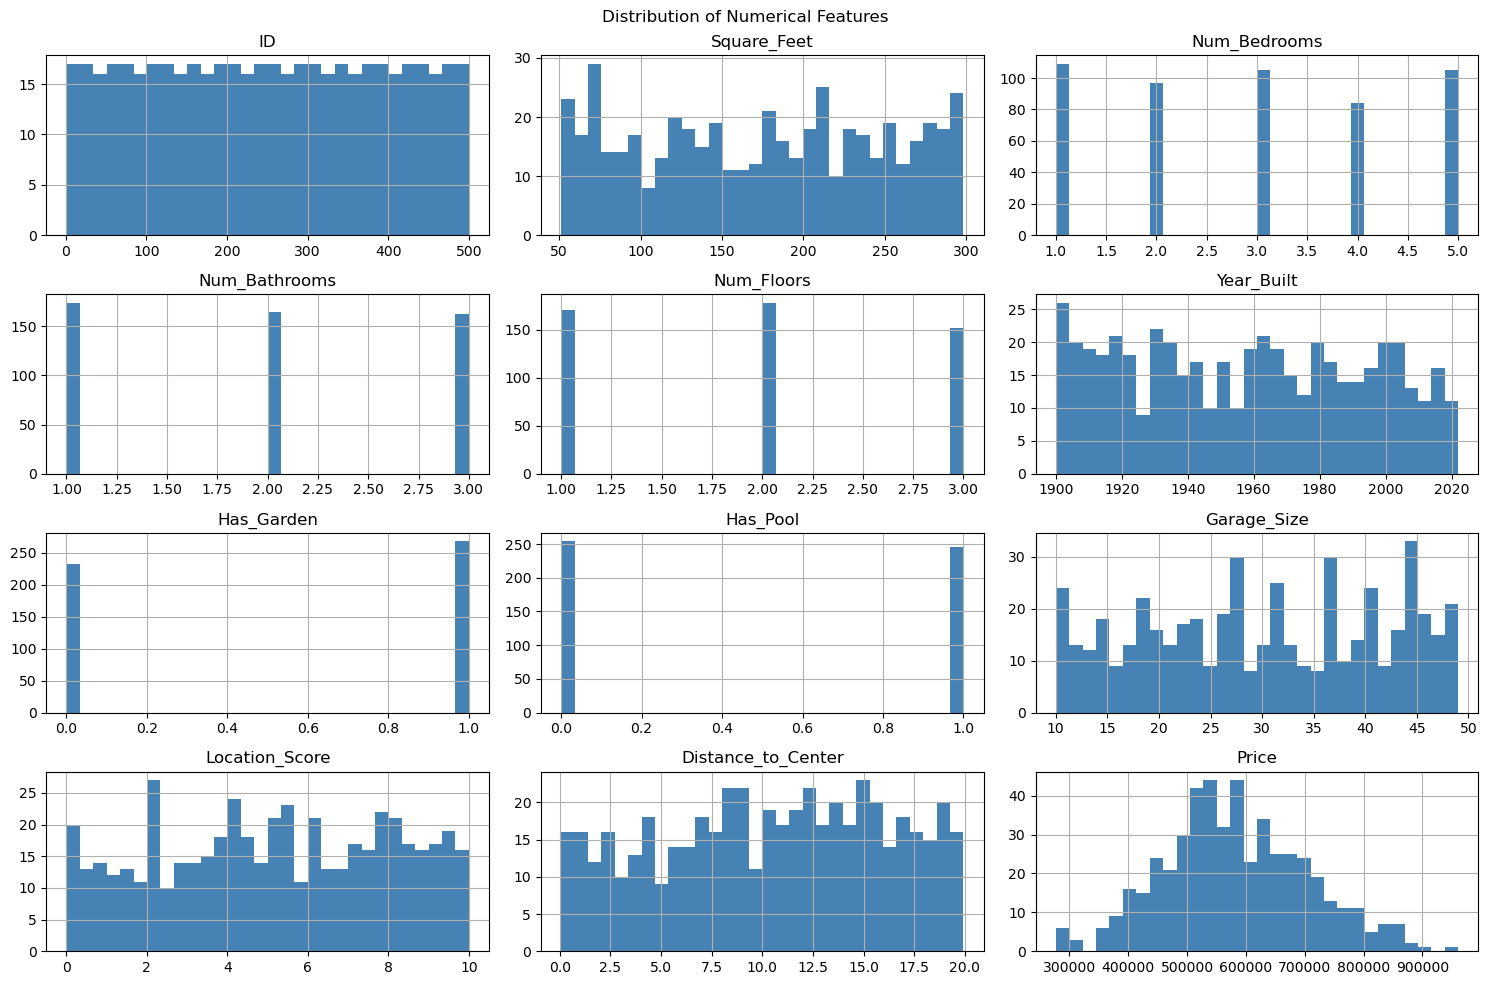

In [36]:
import matplotlib.pyplot as plt

data.select_dtypes(include='number').hist(figsize=(15, 10), bins=30, color='steelblue')
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

In [37]:
# MinMaxScaler (range 0 to 1) → for skewed data

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(data[numerical_cols])
df_scaled = pd.DataFrame(df_scaled, columns=numerical_cols)
print(df_scaled.describe())

               ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  \
count  500.000000   500.000000    500.000000     500.000000  500.000000   
mean     0.500000     0.499543      0.489500       0.488000    0.482000   
std      0.289543     0.302346      0.360242       0.410113    0.401246   
min      0.000000     0.000000      0.000000       0.000000    0.000000   
25%      0.250000     0.239111      0.250000       0.000000    0.000000   
50%      0.500000     0.514324      0.500000       0.500000    0.500000   
75%      0.750000     0.760260      0.750000       1.000000    1.000000   
max      1.000000     1.000000      1.000000       1.000000    1.000000   

       Year_Built  Has_Garden    Has_Pool  Garage_Size  Location_Score  \
count  500.000000  500.000000  500.000000   500.000000      500.000000   
mean     0.472164    0.536000    0.492000     0.517282        0.516462   
std      0.290916    0.499202    0.500437     0.296989        0.285606   
min      0.000000    0.00000

# splitting data set

In [48]:
print(data.columns.tolist())

['ID', 'Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'Price']


In [50]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Location_Score']]   # all input features
y = data['Price']                  # what you want to predict

# 80:20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test
    random_state=42      # for reproducibility
)

print(f"Total rows     : {len(data)}")
print(f"Training rows  : {len(X_train)}")   # 80%
print(f"Testing rows   : {len(X_test)}")    # 20%

Total rows     : 500
Training rows  : 400
Testing rows   : 100


In [51]:
# Train the model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
# Predict on test data
y_pred = model.predict(X_test)

In [53]:
y_pred

array([523446.58297158, 661126.67445771, 514736.19903262, 465990.9362647 ,
       695121.16284928, 611383.66649105, 443565.12719883, 587089.86046581,
       433985.4893323 , 730711.1555837 , 635932.66585136, 534852.1564726 ,
       563892.78757908, 477272.81351695, 593618.92260201, 666836.04110991,
       498295.72187889, 571626.30340988, 660424.75886465, 678208.69906977,
       648068.95795209, 583355.49146064, 731660.88420022, 409047.97157043,
       744295.4077228 , 583573.73710534, 367083.26692132, 701843.81167426,
       579271.52380444, 565622.69505724, 726333.84587438, 756033.8205998 ,
       564239.1243623 , 533058.77557705, 562180.03161186, 599311.22408294,
       371102.29191141, 536486.17665194, 434330.61685581, 531884.1056358 ,
       573993.95870442, 537436.16042544, 655752.00918099, 713752.3081396 ,
       578566.04919951, 541000.814221  , 495615.96477717, 625067.59501127,
       502157.82417228, 468489.66022146, 590531.13222251, 560189.76781324,
       615263.64866404, 5

In [54]:
# Evaluate
import numpy as np
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

In [55]:
print("=== Model Evaluation ===")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

=== Model Evaluation ===
MAE  : 56573.34
MSE  : 4857266308.76
RMSE : 69694.09
R²   : 0.6771


In [56]:
# See which features impact the prediction and by how much
coeff_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n=== Feature Coefficients ===")
print(coeff_df)
print(f"\nIntercept: {model.intercept_:.2f}")


=== Feature Coefficients ===
          Feature   Coefficient
1    Num_Bedrooms  51192.127893
2   Num_Bathrooms  29332.259063
3  Location_Score   3525.858607
0     Square_Feet    957.382478

Intercept: 189657.12


# Based on coefficients Num_Bedrooms has more impact on house price

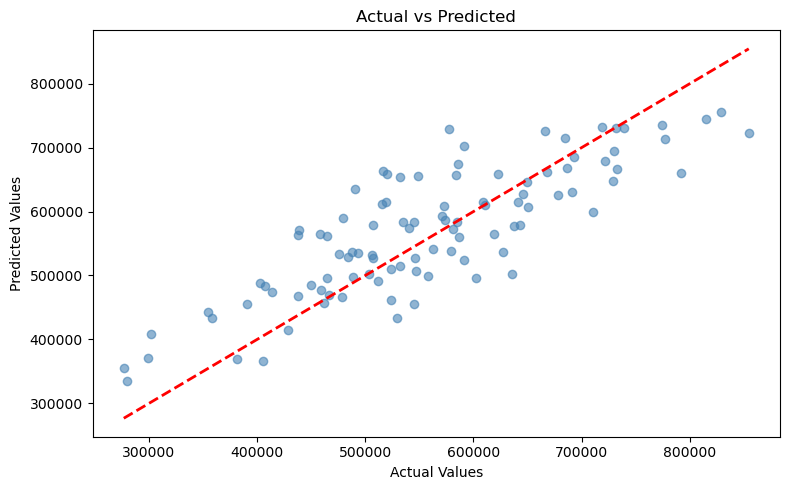

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)   # perfect prediction line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

# Here the points are near to the line so the model is predicting well

In [58]:
# New house details
new_house = pd.DataFrame({
    'Square_Feet'    : [2500],
    'Num_Bedrooms'   : [4],
    'Num_Bathrooms'  : [3],
    'Location_Score' : [8.5]
})

# Predict
predicted_price = model.predict(new_house)

print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")

Predicted House Price: ₹2,905,848.41


# Predicted House Price: ₹2,905,848.41